In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    n_redundant=1,
    n_clusters_per_class=1,
    weights=[0.90, 0.10],
    random_state=42
)

df = pd.DataFrame(
    X,
    columns=[
        "feature_1",
        "feature_2",
        "feature_3",
        "feature_4",
        "feature_5"
    ]
)

df["target"] = y

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (1000, 6)

First 5 rows:
   feature_1  feature_2  feature_3  feature_4  feature_5  target
0  -0.420718  -0.367012  -0.767870   1.651237  -0.593271       0
1   0.311062   0.780386  -1.451478   1.723465  -0.874689       0
2  -1.092120  -1.140347   0.258995   0.898648  -0.474031       0
3   0.111132   1.171272  -0.322178  -1.970000  -1.173218       0
4   0.128437   0.105209  -1.775294   0.743902  -0.587230       0


In [3]:
print("Class distribution before SMOTE:")
print(df["target"].value_counts())

Class distribution before SMOTE:
target
0    897
1    103
Name: count, dtype: int64


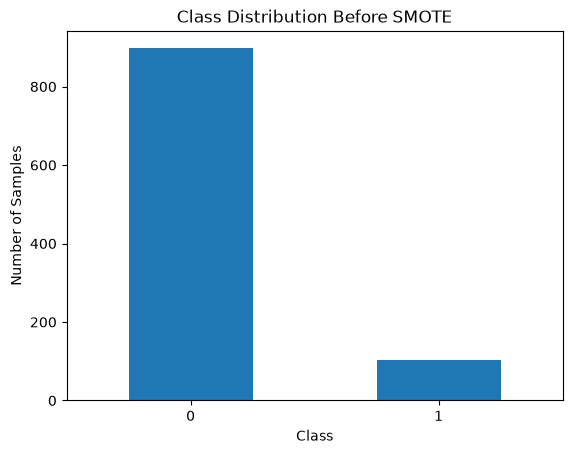

In [4]:
df["target"].value_counts().plot(kind="bar")

plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [5]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [6]:
print("Training class distribution before SMOTE:")
print(y_train.value_counts())

Training class distribution before SMOTE:
target
0    718
1     82
Name: count, dtype: int64


In [7]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Training class distribution after SMOTE:")
print(y_train_smote.value_counts())

Training class distribution after SMOTE:
target
0    718
1    718
Name: count, dtype: int64


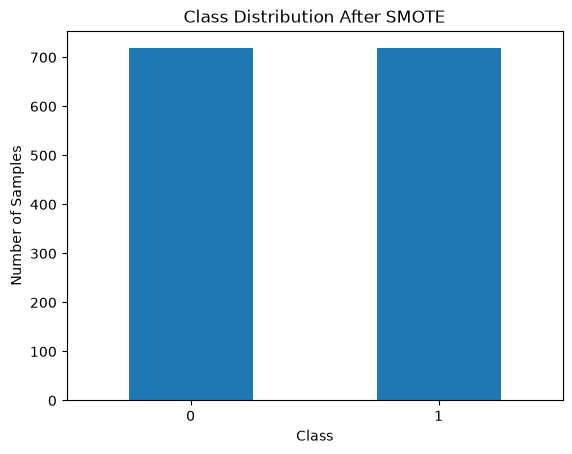

In [8]:
y_train_smote.value_counts().plot(kind="bar")

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [9]:
model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)

print("Model training completed successfully.")

Model training completed successfully.


In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.935

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       179
           1       0.62      1.00      0.76        21

    accuracy                           0.94       200
   macro avg       0.81      0.96      0.86       200
weighted avg       0.96      0.94      0.94       200


Confusion Matrix:
[[166  13]
 [  0  21]]


In [11]:
model_without_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_without_smote.fit(X_train, y_train)

y_pred_without_smote = model_without_smote.predict(X_test)

print("Results without SMOTE:")
print(classification_report(y_test, y_pred_without_smote))

Results without SMOTE:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       179
           1       0.79      0.71      0.75        21

    accuracy                           0.95       200
   macro avg       0.88      0.85      0.86       200
weighted avg       0.95      0.95      0.95       200



In [12]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Minority Precision",
        "Minority Recall",
        "Minority F1-Score"
    ],
    "Without SMOTE": [
        0.95,
        0.79,
        0.71,
        0.75
    ],
    "With SMOTE": [
        0.935,
        0.62,
        1.00,
        0.76
    ]
})

print(comparison)

               Metric  Without SMOTE  With SMOTE
0            Accuracy           0.95       0.935
1  Minority Precision           0.79       0.620
2     Minority Recall           0.71       1.000
3   Minority F1-Score           0.75       0.760


## Conclusion

The dataset was initially imbalanced, with Class 0 having more samples than Class 1.

The data was divided into training and testing sets before applying SMOTE. SMOTE was applied only to the training data to generate synthetic samples for the minority class.

After SMOTE, the training classes became balanced.

A Logistic Regression model was trained using the SMOTE-balanced training data and evaluated on the original test data.

In this experiment, SMOTE increased minority-class recall from 0.71 to 1.00 and minority-class F1-score from 0.75 to 0.76. Overall accuracy changed from 0.95 without SMOTE to 0.935 with SMOTE.

This shows why precision, recall, and F1-score should be considered along with accuracy when evaluating models on imbalanced datasets.